## 퀀트 투자 전략: 5일 이평선-20일 이평선 상향 돌파 매수 신호

In [1]:
# 필요한 라이브러리 임포트
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

### 1. 전략 파라미터 설정

이곳에서 분석할 주식 티커와 데이터 기간을 설정할 수 있습니다. 값을 변경하여 다른 종목이나 기간으로 전략을 테스트해보세요.

In [14]:
# 주식 티커 및 기간 설정
ticker_symbol = 'AAPL'  # 예시: Apple Inc. (원하는 티커로 변경 가능)
start_date = '2023-01-01'
end_date = '2024-01-01'

### 1. 주식 데이터 다운로드

매수 신호를 확인할 주식 티커와 기간을 설정하고 데이터를 다운로드합니다. 여기서는 'AAPL'(Apple Inc.) 주식을 예시로 사용합니다.

In [15]:
# yfinance를 사용하여 데이터 다운로드
df_raw = yf.download(ticker_symbol, start=start_date, end=end_date)

# 'Adj Close' 가격 사용 (주식 분할 등을 고려한 조정된 종가)
# yfinance의 최근 버전에서는 auto_adjust=True 일 때 'Close' 컬럼이 조정된 종가이며,
# 현재 df_raw의 컬럼이 MultiIndex 형태로 반환되었고, 첫 번째 레벨이 데이터 타입(예: 'Close'),
# 두 번째 레벨이 티커 심볼(예: 'AAPL')인 것으로 보입니다.
# 따라서 ('Close', ticker_symbol) 컬럼을 선택하고, 이를 'Adj Close'라는 새 컬럼으로 저장합니다.
# 이렇게 하면 이후 코드에서 'Adj Close' 컬럼을 정상적으로 사용할 수 있습니다.
df = df_raw[('Close', ticker_symbol)].to_frame(name='Adj Close')

display(df.head())

/tmp/ipykernel_15991/4191967702.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_raw = yf.download(ticker_symbol, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


,Adj Close
Date,
2023-01-03,123.096024
2023-01-04,124.365677
2023-01-05,123.046814
2023-01-06,127.574211
2023-01-09,128.095840


### 2. 이동평균선(SMA) 계산

5일 이동평균선(SMA)과 20일 이동평균선을 계산합니다.

In [9]:
# 5일 이동평균선 계산
df['SMA_5'] = df['Adj Close'].rolling(window=5).mean()

# 20일 이동평균선 계산
df['SMA_20'] = df['Adj Close'].rolling(window=20).mean()

display(df.tail())

,Adj Close,SMA_5,SMA_20
Date,,,
2023-12-22,191.609482,193.181143,191.677264
2023-12-26,191.065109,192.618979,191.838589
2023-12-27,191.164078,191.868768,191.974675
2023-12-28,191.589661,191.621335,192.183009
2023-12-29,190.550461,191.195758,192.310683


### 3. 매수 신호 생성

5일 이동평균선이 20일 이동평균선을 상향 돌파할 때 매수 신호를 생성합니다.

In [10]:
# 매수 신호 초기화
df['Buy_Signal'] = 0

# 5일 이평선이 20일 이평선을 상향 돌파할 때 매수 신호 생성
# 조건: 5일 이평선이 20일 이평선보다 크고, 전날은 5일 이평선이 20일 이평선보다 작았을 경우
df['Buy_Signal'] = ((df['SMA_5'] > df['SMA_20']) & (df['SMA_5'].shift(1) <= df['SMA_20'].shift(1))).astype(int)

# 신호가 발생한 날의 종가(Adj Close)를 저장 (매수 시점을 그래프에 표시하기 위함)
df['Buy_Price'] = df['Adj Close'][df['Buy_Signal'] == 1]

display(df[df['Buy_Signal'] == 1].head())

,Adj Close,SMA_5,SMA_20,Buy_Signal,Buy_Price
Date,,,,,
2023-03-08,150.687012,148.891010,148.417779,1,150.687012
2023-08-29,181.987167,177.997931,177.523154,1,181.987167
2023-10-09,176.916595,173.457138,172.680249,1,176.916595
2023-11-06,177.153824,173.603442,172.919952,1,177.153824


### 4. 결과 시각화

종가, 5일 이평선, 20일 이평선, 그리고 매수 신호를 그래프로 시각화하여 전략의 동작을 확인합니다.

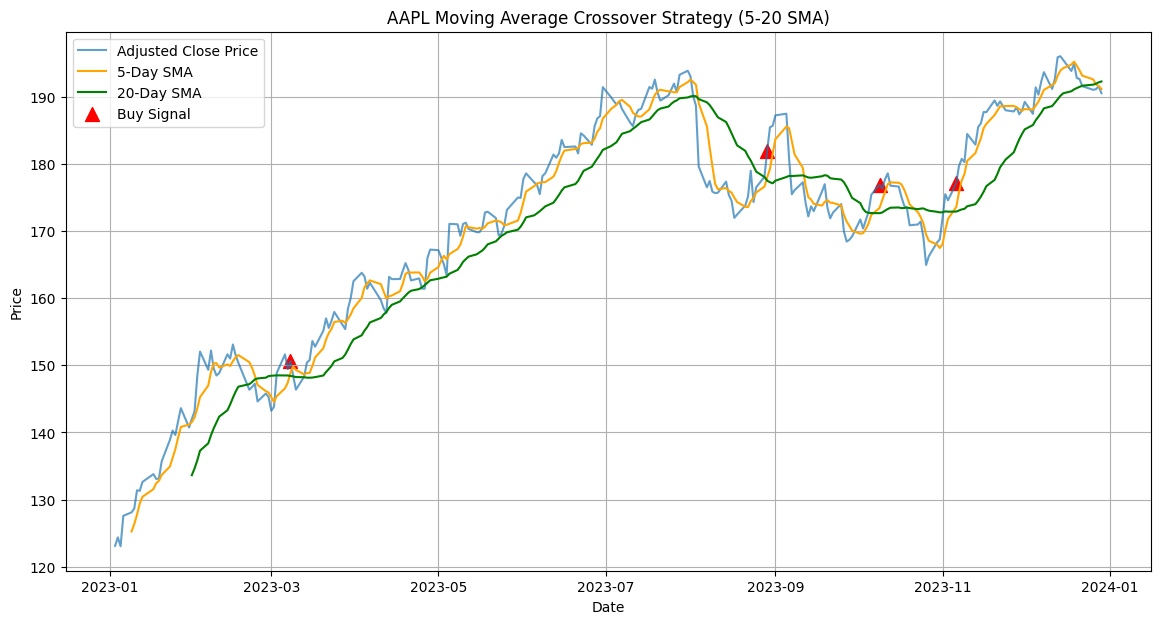

In [11]:
plt.figure(figsize=(14, 7))
plt.plot(df['Adj Close'], label='Adjusted Close Price', alpha=0.7)
plt.plot(df['SMA_5'], label='5-Day SMA', color='orange')
plt.plot(df['SMA_20'], label='20-Day SMA', color='green')
plt.scatter(df.index, df['Buy_Price'], marker='^', color='red', s=100, label='Buy Signal')

plt.title(f'{ticker_symbol} Moving Average Crossover Strategy (5-20 SMA)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

### 5. 백테스팅 (Backtesting)

매수 신호와 매도 신호를 기반으로 간단한 백테스팅을 수행하여 전략의 성과를 평가합니다. 여기서는 5일 이동평균선이 20일 이동평균선을 하향 돌파할 때 매도하는 것으로 가정합니다.

In [12]:
# 매도 신호 생성 (5일 이평선이 20일 이평선을 하향 돌파할 때)
df['Sell_Signal'] = 0
df['Sell_Signal'] = ((df['SMA_5'] < df['SMA_20']) & (df['SMA_5'].shift(1) >= df['SMA_20'].shift(1))).astype(int)

# 백테스팅을 위한 컬럼 초기화
df['Position'] = 0 # 1이면 매수 포지션, 0이면 포지션 없음
df['Strategy_Return'] = 0.0

# 백테스팅 로직
position = 0
buy_price = 0
trades = [] # (buy_date, buy_price, sell_date, sell_price, return)

for i in range(1, len(df)):
    # 매수 신호가 발생하고 현재 포지션이 없는 경우
    if df['Buy_Signal'].iloc[i] == 1 and position == 0:
        position = 1
        buy_price = df['Adj Close'].iloc[i]
        # 매수 신호 발생일의 종가를 기록 (실제 매수는 다음날 시가로 이루어질 수 있으나, 단순화를 위해 당일 종가로 가정)
        df.loc[df.index[i], 'Position'] = 1

    # 매도 신호가 발생하고 현재 포지션이 있는 경우
    elif df['Sell_Signal'].iloc[i] == 1 and position == 1:
        position = 0
        sell_price = df['Adj Close'].iloc[i]
        trade_return = (sell_price - buy_price) / buy_price
        trades.append({'buy_date': df.index[i-1], 'buy_price': buy_price, 'sell_date': df.index[i], 'sell_price': sell_price, 'return': trade_return})
        # 매도 신호 발생일의 종가를 기록
        df.loc[df.index[i], 'Position'] = -1 # -1은 매도(포지션 청산)를 의미
        df.loc[df.index[i], 'Strategy_Return'] = trade_return

# 마지막에 포지션이 열려있으면 마지막 종가로 청산 가정
if position == 1:
    sell_price = df['Adj Close'].iloc[-1]
    trade_return = (sell_price - buy_price) / buy_price
    trades.append({'buy_date': df.index[i-1], 'buy_price': buy_price, 'sell_date': df.index[-1], 'sell_price': sell_price, 'return': trade_return})

# 매매가 이루어지지 않은 날은 0% 수익률로 채움
# df['Strategy_Return'].fillna(0, inplace=True)

# 누적 수익률 계산 (백테스팅 기간 동안의 전체 수익률)
# 매수 및 매도 지점에서만 수익률이 발생하므로, 이를 바탕으로 포트폴리오 가치를 계산합니다.
portfolio_value = [1.0] # 초기 포트폴리오 가치 1로 시작
current_portfolio_value = 1.0

for i in range(1, len(df)):
    if df['Position'].iloc[i] == -1: # 매도 시점
        current_portfolio_value *= (1 + df['Strategy_Return'].iloc[i])
    portfolio_value.append(current_portfolio_value)

df['Cumulative_Strategy_Return'] = portfolio_value

# 기준 수익률 (Buy and Hold)
initial_price = df['Adj Close'].iloc[0]
df['Buy_and_Hold_Return'] = (df['Adj Close'] / initial_price)

display(df[['Adj Close', 'SMA_5', 'SMA_20', 'Buy_Signal', 'Sell_Signal', 'Position', 'Strategy_Return', 'Cumulative_Strategy_Return', 'Buy_and_Hold_Return']].tail())

print(f"Total trades: {len(trades)}")
if len(trades) > 0:
    winning_trades = [t for t in trades if t['return'] > 0]
    losing_trades = [t for t in trades if t['return'] <= 0]
    win_rate = len(winning_trades) / len(trades) * 100
    total_strategy_return = (df['Cumulative_Strategy_Return'].iloc[-1] - 1) * 100
    total_buy_and_hold_return = (df['Buy_and_Hold_Return'].iloc[-1] - 1) * 100

    print(f"Winning trades: {len(winning_trades)}")
    print(f"Losing trades: {len(losing_trades)}")
    print(f"Win Rate: {win_rate:.2f}%")
    print(f"Total Strategy Return: {total_strategy_return:.2f}%")
    print(f"Total Buy and Hold Return: {total_buy_and_hold_return:.2f}%")

,Adj Close,SMA_5,SMA_20,Buy_Signal,Sell_Signal,Position,Strategy_Return,Cumulative_Strategy_Return,Buy_and_Hold_Return
Date,,,,,,,,,
2023-12-22,191.609482,193.181143,191.677264,0,0,0,0.000000,1.103302,1.556585
2023-12-26,191.065109,192.618979,191.838589,0,0,0,0.000000,1.103302,1.552163
2023-12-27,191.164078,191.868768,191.974675,0,1,-1,0.079085,1.190557,1.552967
2023-12-28,191.589661,191.621335,192.183009,0,0,0,0.000000,1.190557,1.556424
2023-12-29,190.550461,191.195758,192.310683,0,0,0,0.000000,1.190557,1.547982


Total trades: 4
Winning trades: 2
Losing trades: 2
Win Rate: 50.00%
Total Strategy Return: 19.06%
Total Buy and Hold Return: 54.80%


### 6. 누적 수익률 시각화

전략의 누적 수익률과 단순 '매수 후 보유(Buy and Hold)' 전략의 누적 수익률을 비교합니다.

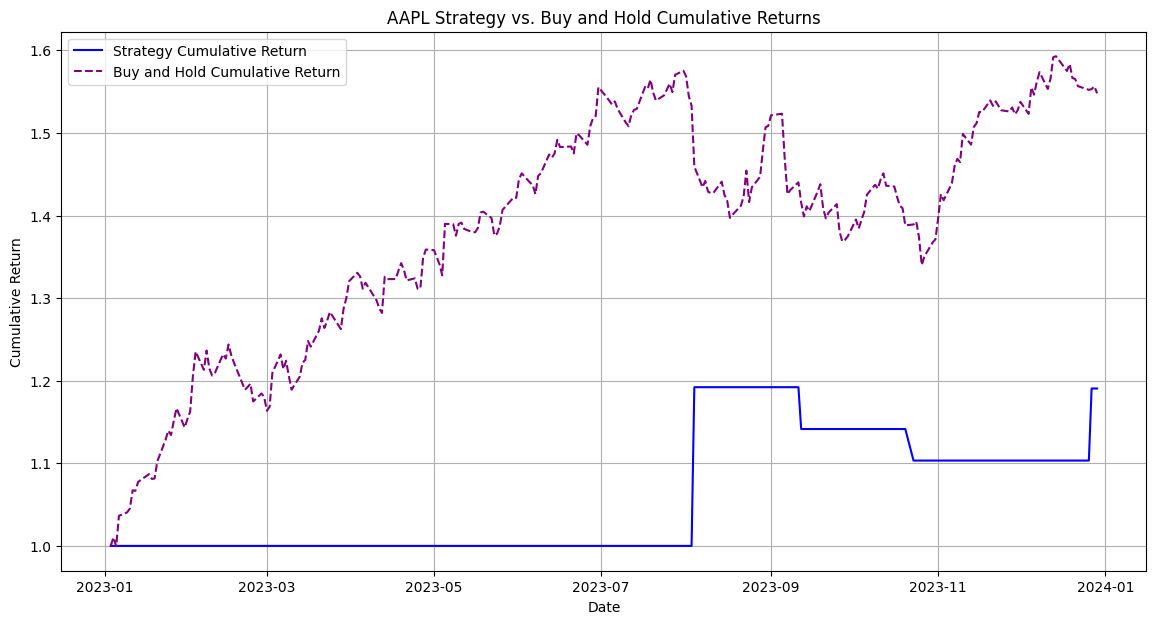

In [13]:
plt.figure(figsize=(14, 7))
plt.plot(df['Cumulative_Strategy_Return'], label='Strategy Cumulative Return', color='blue')
plt.plot(df['Buy_and_Hold_Return'], label='Buy and Hold Cumulative Return', color='purple', linestyle='--')

plt.title(f'{ticker_symbol} Strategy vs. Buy and Hold Cumulative Returns')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid(True)
plt.show()